# StockBot: Vanilla LSTM for Stock Price Forecasting
Implements the stacked LSTM from *StockBot 2.0* (Mohanty, 2026).  
Trains a sliding-window model (60-day input → 1-day-ahead output) with Adam, MSE loss, and early stopping. At inference, the model receives the preceding 60 actual days and predicts the next day — no autoregressive feedback.

In [204]:
%pip install -q yfinance torch numpy scikit-learn matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


## 0. Dataset Setup
Downloads the CSV from GitHub if not available locally (e.g. on Colab).

In [205]:
import os, urllib.request

CSV_NAME   = 'aapl_daily_sentiment_2021_2025.csv'
RAW_URL    = ('https://raw.githubusercontent.com/franciscomartinez45/'
              'Stock-Forecasting-LSTM/main/data/processed/' + CSV_NAME)
LOCAL_PATHS = [f'../data/processed/{CSV_NAME}', CSV_NAME]

if not any(os.path.exists(p) for p in LOCAL_PATHS):
    print('Downloading dataset from GitHub...')
    urllib.request.urlretrieve(RAW_URL, CSV_NAME)
    print('Done.')
else:
    print('Dataset found locally.')

Dataset found locally.


## 1. Imports & Config

In [206]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

# ── Hyperparameters (Table 1 from paper) ──────────────────────────────────
TICKER           = 'AAPL'           # swap to any yfinance-supported ticker
START_DATE       = '2021-05-01'
END_DATE         = '2025-12-31'
PAST_HISTORY     = 60               # days of history per input window
FORECAST_HORIZON = 10               # days ahead to predict (one-shot)
HIDDEN_DIM       = 64
NUM_LAYERS       = 1
DROPOUT          = 0.1
BATCH_SIZE       = 64
LR               = 1e-3
EPOCHS           = 500
PATIENCE         = 15
TRAIN_RATIO      = 0.8

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

Device: mps


## 2. Data
Adjusted close prices, z-score normalised using **training-set statistics only** to prevent leakage.

In [207]:
import yfinance as yf

def load_prices():
    df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
    return df['Close'].values.flatten().astype(np.float32), df.index.tolist()

prices_raw, dates = load_prices()
n          = len(prices_raw)
train_size = int(n * TRAIN_RATIO)

scaler    = StandardScaler()
prices_sc = np.concatenate([
    scaler.fit_transform(prices_raw[:train_size].reshape(-1, 1)).flatten(),
    scaler.transform(prices_raw[train_size:].reshape(-1, 1)).flatten(),
])

print(f'Total: {n} days | Train: {train_size} | Test: {n - train_size}')

Total: 1172 days | Train: 937 | Test: 235


In [208]:
class StockDataset(Dataset):
    def __init__(self, prices):
        self.x = torch.tensor(prices, dtype=torch.float32).unsqueeze(-1)  # (T, 1)

    def __len__(self):
        return len(self.x) - PAST_HISTORY - FORECAST_HORIZON + 1

    def __getitem__(self, idx):
        x = self.x[idx : idx + PAST_HISTORY]
        y = self.x[idx + PAST_HISTORY : idx + PAST_HISTORY + FORECAST_HORIZON, 0]
        return x, y

val_cut  = int(train_size * 0.9)
train_ds = StockDataset(prices_sc[:val_cut])
val_ds   = StockDataset(prices_sc[val_cut - PAST_HISTORY : train_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
print(f'Train: {len(train_ds)} samples | Val: {len(val_ds)} samples')

Train: 774 samples | Val: 85 samples


## 3. Model
Stacked LSTM (Equations 1–6 from paper). The final hidden state is projected to a scalar price prediction.

In [209]:
class StackedLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = 1,
            hidden_size = HIDDEN_DIM,
            num_layers  = NUM_LAYERS,
            batch_first = True,
            dropout     = DROPOUT if NUM_LAYERS > 1 else 0.0,
        )
        self.fc = nn.Linear(HIDDEN_DIM, FORECAST_HORIZON)

    def forward(self, x):          # x: (batch, seq, 1)
        out, _ = self.lstm(x)      # (batch, seq, hidden)
        return self.fc(out[:, -1, :])  # (batch, FORECAST_HORIZON)

## 4. Training
Adam + weighted MSE loss (Eq. 9 from paper) with early stopping on validation loss.  
Weight `wᵢ = 1 + (FORECAST_HORIZON − 1 − i) / 200` penalises predictions further from the anchor more heavily, correcting for the convergence bias observed in multi-step forecasting.

Epoch  10 | Train 0.0586 | Val 0.1655
Epoch  20 | Train 0.0523 | Val 0.1662
Epoch  30 | Train 0.0487 | Val 0.1794
Epoch  40 | Train 0.0472 | Val 0.1693
Epoch  50 | Train 0.0451 | Val 0.1444
Early stop at epoch 56


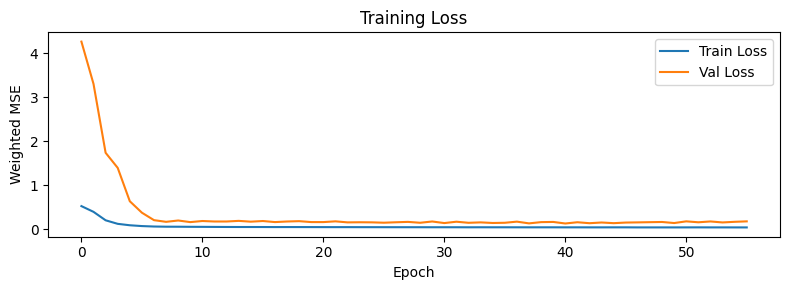

In [210]:
model     = StackedLSTM().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Weighted MSE: w_i = 1 + (FORECAST_HORIZON-1-i)/200  (Eq. 9, Mohanty et al.)
# Steps closer to the anchor get higher weight; target day gets weight 1.0.
t       = np.arange(FORECAST_HORIZON - 1, -1, -1)          # [H-1, H-2, ..., 0]
weights = torch.tensor(1 + t / 200, dtype=torch.float32).to(DEVICE)  # (H,)

def weighted_mse(pred, target):
    return (weights * (pred - target) ** 2).mean()

best_val, patience_count = float('inf'), 0
tr_losses, vl_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr = 0.0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = weighted_mse(model(x), y)
        loss.backward()
        optimizer.step()
        tr += loss.item()

    model.eval()
    vl = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            vl += weighted_mse(model(x.to(DEVICE)), y.to(DEVICE)).item()

    tr_losses.append(tr / len(train_loader))
    vl_losses.append(vl / max(len(val_loader), 1))

    if vl_losses[-1] < best_val:
        best_val, patience_count = vl_losses[-1], 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'Early stop at epoch {epoch}')
            break

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Train {tr_losses[-1]:.4f} | Val {vl_losses[-1]:.4f}')

os.makedirs('plots', exist_ok=True)

plt.figure(figsize=(8, 3))
plt.plot(tr_losses, label='Train Loss')
plt.plot(vl_losses, label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Weighted MSE'); plt.legend()
plt.title('Training Loss'); plt.tight_layout()
plt.savefig('plots/training_loss.png', dpi=150)
plt.show()

## 5. Multi-Step Forecasting
At each step the model receives 60 actual trading days and predicts the next {FORECAST_HORIZON} days directly — no autoregressive feedback. The window slides by {FORECAST_HORIZON} to produce non-overlapping forecasts across the test set.

In [211]:
@torch.no_grad()
def sliding_window_forecast(n_steps):
    model.eval()
    preds = []
    i = 0
    while i + FORECAST_HORIZON <= n_steps:
        start = train_size - PAST_HISTORY + i
        x = torch.tensor(prices_sc[start : start + PAST_HISTORY],
                         dtype=torch.float32).view(1, PAST_HISTORY, 1).to(DEVICE)
        pred = model(x).squeeze(0).cpu().numpy()  # (FORECAST_HORIZON,)
        preds.append(pred)
        i += FORECAST_HORIZON
    return np.concatenate(preds)

RMSE: $19.59


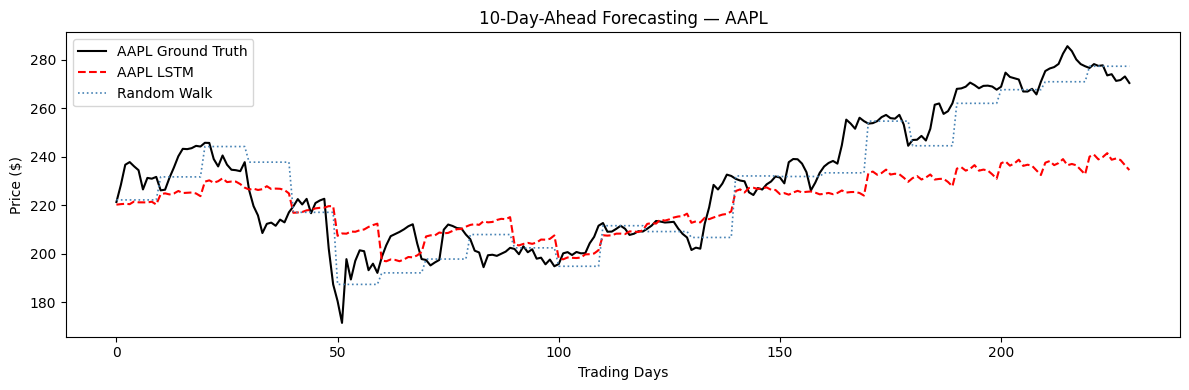

In [212]:
n_test     = n - train_size
preds_sc   = sliding_window_forecast(n_test)
n_preds    = len(preds_sc)
gt_sc      = prices_sc[train_size : train_size + n_preds]
test_dates = dates[train_size : train_size + n_preds]

inv    = lambda x: scaler.inverse_transform(x.reshape(-1, 1)).flatten()
actual = inv(gt_sc)
preds  = inv(preds_sc)

# Random walk: for each 10-day window, predict the last known price (anchor)
# repeated across all FORECAST_HORIZON steps.
# Anchors: prices_raw[train_size-1], prices_raw[train_size+9], prices_raw[train_size+19], ...
rw_preds = np.repeat(
    prices_raw[train_size - 1 : train_size + n_preds - 1 : FORECAST_HORIZON],
    FORECAST_HORIZON
)[:n_preds]

rmse = np.sqrt(np.mean((preds - actual) ** 2))
print(f'RMSE: ${rmse:.2f}')

plt.figure(figsize=(12, 4))
plt.plot(actual,   color='black',    label=f'{TICKER} Ground Truth', linewidth=1.5)
plt.plot(preds,    color='red',      label=f'{TICKER} LSTM',         linestyle='--')
plt.plot(rw_preds, color='steelblue',label='Random Walk',            linestyle=':',  linewidth=1.2)
plt.title(f'{FORECAST_HORIZON}-Day-Ahead Forecasting — {TICKER}')
plt.xlabel('Trading Days'); plt.ylabel('Price ($)'); plt.legend()
plt.tight_layout()
plt.savefig(f'plots/{TICKER}_forecast.png', dpi=150)
plt.show()

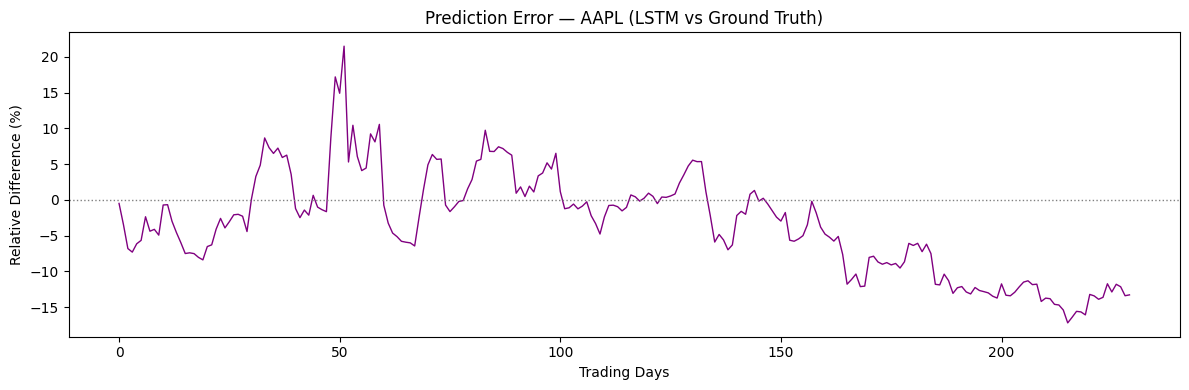

Mean error:  -3.30%
Max error:   21.51%
Min error:   -17.20%


In [213]:
pct_diff = (preds - actual) / actual * 100

plt.figure(figsize=(12, 4))
plt.plot(pct_diff, color='purple', linewidth=1)
plt.axhline(0, color='gray', linestyle=':', linewidth=1)
plt.title(f'Prediction Error — {TICKER} (LSTM vs Ground Truth)')
plt.xlabel('Trading Days'); plt.ylabel('Relative Difference (%)')
plt.tight_layout()
plt.savefig(f'plots/{TICKER}_prediction_error.png', dpi=150)
plt.show()

print(f'Mean error:  {pct_diff.mean():.2f}%')
print(f'Max error:   {pct_diff.max():.2f}%')
print(f'Min error:   {pct_diff.min():.2f}%')

## 5b. Baseline Comparison — LSTM vs Random Walk

Metric                       LSTM  Random Walk
----------------------------------------------
RMSE ($)                   19.59        10.17
MAPE (%)                    6.18%        3.43%
Directional Acc (%)         50.0%         0.0%


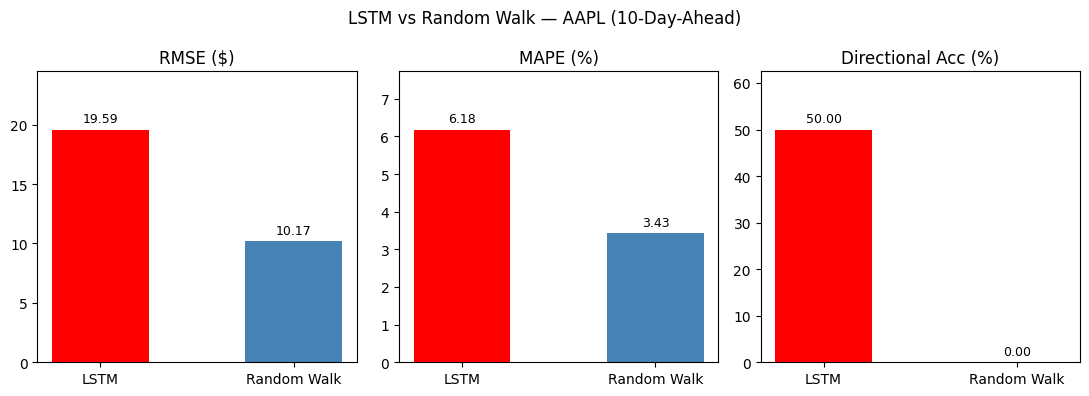

In [214]:
# ── Metrics ───────────────────────────────────────────────────────────────
rmse_lstm = np.sqrt(np.mean((preds    - actual) ** 2))
rmse_rw   = np.sqrt(np.mean((rw_preds - actual) ** 2))

mape_lstm = np.mean(np.abs((preds    - actual) / actual)) * 100
mape_rw   = np.mean(np.abs((rw_preds - actual) / actual)) * 100

# Directional accuracy: did the model predict the correct direction vs the window anchor?
# For each 10-day window the anchor is the last known price before that window.
anchors = np.repeat(
    prices_raw[train_size - 1 : train_size + n_preds - 1 : FORECAST_HORIZON],
    FORECAST_HORIZON
)[:n_preds]

true_dir = np.sign(actual - anchors)
lstm_dir = np.sign(preds  - anchors)
dir_acc_lstm = np.mean(true_dir == lstm_dir) * 100
dir_acc_rw   = 0.0   # always predicts anchor → never gets direction right

print(f"{'Metric':<22} {'LSTM':>10} {'Random Walk':>12}")
print("-" * 46)
print(f"{'RMSE ($)':<22} {rmse_lstm:>9.2f}  {rmse_rw:>11.2f}")
print(f"{'MAPE (%)':<22} {mape_lstm:>9.2f}%  {mape_rw:>10.2f}%")
print(f"{'Directional Acc (%)':<22} {dir_acc_lstm:>9.1f}%  {dir_acc_rw:>10.1f}%")

# ── Bar chart ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
metrics   = ['RMSE ($)', 'MAPE (%)', 'Directional Acc (%)']
lstm_vals = [rmse_lstm, mape_lstm, dir_acc_lstm]
rw_vals   = [rmse_rw,   mape_rw,   dir_acc_rw]

for ax, metric, lv, rv in zip(axes, metrics, lstm_vals, rw_vals):
    bars = ax.bar(['LSTM', 'Random Walk'], [lv, rv], color=['red', 'steelblue'], width=0.5)
    ax.set_title(metric)
    ax.set_ylim(0, max(lv, rv) * 1.25)
    for bar, val in zip(bars, [lv, rv]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(lv, rv) * 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

fig.suptitle(f'LSTM vs Random Walk — {TICKER} ({FORECAST_HORIZON}-Day-Ahead)', fontsize=12)
plt.tight_layout()
plt.savefig(f'plots/{TICKER}_baseline_comparison.png', dpi=150)
plt.show()

## 6. StockBot Trading Strategy
Uses Algorithm 1 from the paper: δᵢ = sign(cᵢ₊₁ − cᵢ), Δᵢ = δᵢ₊₁ − δᵢ.  
Buy when Δᵢ = +2 (local minimum in predicted prices — prices were falling, now rising), sell when Δᵢ = −2 (local maximum — prices were rising, now falling).

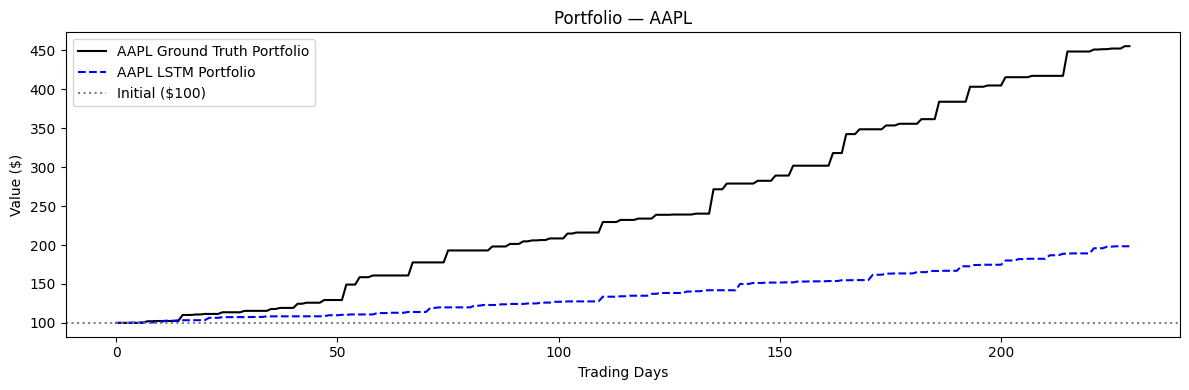

LSTM portfolio final value:         $198.39
Ground truth portfolio final value: $455.42


In [215]:
def stockbot_portfolio(prices, capital=100.0):
    delta = np.sign(np.diff(prices)).astype(int)  # direction of change
    Delta = np.diff(delta)                         # curvature
    held, buy_price, cur = False, 0.0, capital
    portfolio = [cur]
    for i, d in enumerate(Delta):
        signal_price = prices[i + 1]
        if d == 2 and not held:       # local min → buy
            held, buy_price = True, signal_price
        elif d == -2 and held:        # local max → sell
            held = False
            cur *= signal_price / buy_price
        portfolio.append(cur)
    portfolio.append(cur)             # final day
    return np.array(portfolio)

lstm_port = stockbot_portfolio(preds)
gt_port   = stockbot_portfolio(actual)

plt.figure(figsize=(12, 4))
plt.plot(gt_port,   color='black', label=f'{TICKER} Ground Truth Portfolio', linewidth=1.5)
plt.plot(lstm_port, color='blue',  label=f'{TICKER} LSTM Portfolio',         linestyle='--')
plt.axhline(100, color='gray', linestyle=':', label='Initial ($100)')
plt.ticklabel_format(useOffset=False, style='plain')
plt.title(f'Portfolio — {TICKER}')
plt.xlabel('Trading Days'); plt.ylabel('Value ($)'); plt.legend()
plt.tight_layout()
plt.savefig(f'plots/{TICKER}_portfolio.png', dpi=150)
plt.show()

print(f'LSTM portfolio final value:         ${lstm_port[-1]:.2f}')
print(f'Ground truth portfolio final value: ${gt_port[-1]:.2f}')